# 11 — Familia F7: redes neuronales / aprendizaje no supervisado moderno

**Qué detecta.** Regímenes como grupos en un **espacio de representación aprendido**: una
red comprime el vector diario de features causales a un código de baja dimensión y un
modelo de mezcla agrupa ese código; el grupo de mayor volatilidad es la crisis. Como
subproducto, el **error de reconstrucción** mide lo "raro" que es cada día para la red.

**Supuestos.** Existe una variedad de baja dimensión donde los regímenes son más separables
que en el espacio original, y hay **datos suficientes** para aprenderla sin memorizarla. No
supone normalidad de los retornos. No impone persistencia temporal (como cualquier
clustering puntual).

**Detector que incluye.**

| id | detector | implementación | papel |
|---|---|---|---|
| D12 | Autoencoder ligero + GMM en el latente | `regimenes.detectores.f7_deep.deep_ae_regime.DeepAERegime` | exploratorio: contraste ablativo frente a un reductor lineal |

El baseline ablativo **PCA → GMM** (`PCAGMMBaseline`, mismo fichero; no registrado en el
benchmark) se reevalúa aquí con el mismo protocolo (§5) para aislar el efecto de la **no
linealidad**.

**Fuentes.** Teoría: `docs/teoria/F7_redes_neuronales.md` y `docs/teoria/00_estado_del_arte.md`;
ficha: `docs/detectores/D12_deep_ae_regime.md`; notebook de la Capa 1:
`capa1-final:capa1_exploracion/notebooks/12_deep_ae_regime.ipynb` (tag git `capa1-final`). Claves de
`docs/references.bib`.

**Índice**
1. [Teoría de la familia](#s1)
2. [Configuración (desde el registro)](#s2)
3. [Ejecución y carga de resultados](#s3)
4. [D12 por pista: estados OOS, diagnóstico del autoencoder, cobertura por crisis, métricas y ranking](#s4)
5. [Comparación intra-familia: AE→GMM frente a PCA→GMM, pista A vs B](#s5)
6. [Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2](#s6)
   - [6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)](#s6-cp2)
7. [Fortalezas, limitaciones y conclusión](#s7)

> **Regla de lectura.** Toda cifra que aparece en el texto sale de una celda; los
> párrafos en markdown solo razonan de forma cualitativa.

<a id="s1"></a>
## 1. Teoría de la familia

### 1.1 Tres lógicas bajo el mismo paraguas
1. **Representación → clustering.** Un autoencoder (AE) o un VAE comprime las features a
   un latente y se agrupa el latente (k-means/GMM), o se aprenden ambas cosas a la vez (DEC,
   [nn_xie2016]).
2. **Anomalía por reconstrucción.** Una red entrenada en periodos normales reconstruye mal
   las configuraciones de estrés: el error de reconstrucción es un índice continuo de
   "rareza" [nn_ancho2015].
3. **Secuencial (LSTM/GRU).** Redes recurrentes con memoria [nn_hochreiter1997]; para
   regímenes exigen etiquetas que no existen (no hay ground-truth de régimen) o se usan como
   codificador dentro de un AE secuencial.

A estas se suman los **mapas autoorganizados** (SOM, [nn_kohonen1990]), útiles para
visualizar, y los **híbridos** deep + HMM, donde la red solo reduce y la dinámica la pone un
modelo de estados [nn_nystrup2018].

### 1.2 Autoencoder
Un codificador $f_\phi:\mathbb{R}^p\to\mathbb{R}^d$ y un decodificador
$g_\theta:\mathbb{R}^d\to\mathbb{R}^p$ con $d\ll p$ se entrenan para reconstruir la entrada
[nn_hinton2006; nn_goodfellow2016]:

$$
\min_{\phi,\theta}\ \frac{1}{n}\sum_{i=1}^{n}\big\lVert x_i - g_\theta(f_\phi(x_i))\big\rVert_2^2
\;+\; \lambda\,\big(\lVert\phi\rVert_2^2 + \lVert\theta\rVert_2^2\big).
$$

Un AE **lineal** con pérdida cuadrática recupera el subespacio de las $d$ primeras
componentes principales: la PCA es, literalmente, el AE sin no linealidades. Por eso
**PCA → GMM con la misma $d$ y el mismo $K$** es el contraste que aísla lo único que el AE
añade —la no linealidad—; Hinton y Salakhutdinov plantean precisamente el AE como
generalización no lineal de la PCA [nn_hinton2006].

### 1.3 VAE y probabilidad de reconstrucción
El VAE hace el latente probabilístico y maximiza la cota inferior de la evidencia
[nn_kingma2014]:

$$
\mathcal{L}(x) = \mathbb{E}_{q_\phi(z\mid x)}\big[\log p_\theta(x\mid z)\big] - \mathrm{KL}\big(q_\phi(z\mid x)\,\Vert\,p(z)\big),
$$

con un latente más suave (y riesgo de *posterior collapse* con pocos datos). La
"probabilidad de reconstrucción" del VAE es la base del detector de anomalías de An y Cho
[nn_ancho2015]. D12 usa un AE determinista, más simple y con menos grados de libertad.

### 1.4 GMM sobre el latente
Sobre el código $z_i = f_\phi(x_i)$ se ajusta una mezcla gaussiana de covarianza completa,

$$
p(z) = \sum_{k=1}^{K}\pi_k\,\mathcal{N}(z;\mu_k,\Sigma_k),\qquad
\gamma_{ik} = \frac{\pi_k\,\mathcal{N}(z_i;\mu_k,\Sigma_k)}{\sum_j \pi_j\,\mathcal{N}(z_i;\mu_j,\Sigma_j)},
$$

el estado es $\arg\max_k\gamma_{ik}$ y $p^{\text{crisis}}_i=\gamma_{i,\text{crisis}}$. Es el
esquema de D03 (familia F2) pero sobre el código aprendido. El orden canónico
(0 = calma … $K-1$ = crisis) lo fija el núcleo con la volatilidad de los retornos del
S&P 500 de cada estado. Al ser puntual, **no hay persistencia**: el estado puede parpadear
día a día.

### 1.5 Variantes descartadas
DEC [nn_xie2016] exige código a medida y fue validado en conjuntos grandes; el LSTM
supervisado necesita etiquetas de régimen que no existen; los SOM sirven para explorar, no
como detector causal. Los trabajos aplicados más sólidos son sobrios: PCA + k-means para
regímenes macro-financieros [nn_akioyamen2021], y la comparación de Bucci y Ciciretti, donde
un modelo econométrico no lineal etiqueta mejor los regímenes que el clustering no
supervisado [nn_bucci2021]. Bao et al. [nn_bao2017] ilustran además cómo un preprocesado no
causal infla resultados.

### 1.6 El problema de fondo: pocos datos efectivos y pocas crisis
Una red tiene muchos parámetros; las series diarias están fuertemente autocorrelacionadas
(el número efectivo de observaciones independientes es muy inferior al de sesiones) y los
episodios de crisis se cuentan en decenas, no en miles. El riesgo de ajustar ruido y de
*backtest overfitting* es el que advierte López de Prado [lopezdeprado2018]. La receta del
estado del arte: un único representante **ligero, regularizado y no supervisado**, marcado
como exploratorio, con un resultado negativo aceptable como contribución.

### 1.7 D12 y la causalidad
Dos fuentes de *look-ahead* en deep learning: (i) la **normalización** —D12 re-estandariza
con media y desviación del **train del fold** y las congela— y (ii) el **entrenamiento** —el
walk-forward reentrena AE y GMM desde cero en cada fold y codifica el bloque de test con la
red congelada (`eval()`, sin gradiente)—. El codificador es puntual, así que ocultar el
futuro no cambia los estados del bloque (en la Capa 1 se verificó la invariancia de
estados; el latente solo difiere por ruido de coma flotante de `float32`). El AE no es
generativo: `score`, AIC y BIC son NaN.

**Referencias:** `nn_hochreiter1997`, `nn_hinton2006`, `nn_kingma2014`, `nn_xie2016`,
`nn_ancho2015`, `nn_kohonen1990`, `nn_goodfellow2016`, `nn_bao2017`, `nn_akioyamen2021`,
`nn_bucci2021`, `nn_nystrup2018`, `lopezdeprado2018`.

<a id="s2"></a>
## 2. Configuración (desde el registro)

La tabla se genera del registro: features, parámetros, semilla, paso de reentrenamiento,
ventana de entrenamiento y pista. La arquitectura efectiva se imprime desde el propio
detector.

In [1]:
%matplotlib inline
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from regimenes import informes as inf
from regimenes import rutas, viz
from regimenes.benchmark import DEFAULT_TRAIN_DAYS, configure_evaluation
from regimenes.detectores.registry import SEED
from regimenes.evaluacion import ranking as rk
from regimenes.evaluacion.walk_forward import CONTEXT_YEARS
from regimenes import evaluacion as ev
from regimenes.benchmark import common_track_index, run_benchmark
from regimenes.evaluacion.metricas import detection_summary
try:
    import torch
    from regimenes.detectores.f7_deep.deep_ae_regime import DeepAERegime, PCAGMMBaseline
except ImportError as exc:  # torch es el extra opcional [deep]
    raise ImportError('D12 necesita PyTorch: pip install -e .[deep]') from exc

# --- Configuración común a los notebooks de familia 05–11 ---------------------------------
FAMILIA = 'f7_deep'                  # figuras en results/detectores/<FAMILIA>/
NOMBRE_FAMILIA = 'F7 — Redes neuronales (autoencoder)'
DETECTORES = ['D12']
PISTAS = ['A', 'B']
OUTPUT_DIR = rutas.RESULTS_BENCHMARK        # caché del benchmark (aquí solo se lee)
FIG_DIR = inf.carpeta_figuras(FAMILIA)
SPECS = inf.specs_familia(DETECTORES, PISTAS)   # {(pista, id): DetectorSpec} del registro
MIN_RUN = int(rk.DETECTION_DEFAULTS['min_run'])
BETA = float(rk.DETECTION_DEFAULTS['beta'])
rel = inf.ruta_relativa

viz.use_house_style()
inf.opciones_pandas()
warnings.filterwarnings('ignore', category=FutureWarning)


def guardar(fig, nombre):
    """Guarda en results/detectores/<FAMILIA>/<nombre>.png con el estilo de casa (convención 05–11)."""
    return inf.guardar_figura(fig, FIG_DIR, nombre)


# --- Constantes propias de la familia -----------------------------------------------------
warnings.filterwarnings('ignore')

print(f'Familia {NOMBRE_FAMILIA}: {", ".join(DETECTORES)} | pistas {", ".join(PISTAS)}')
print('Resultados benchmark :', rel(OUTPUT_DIR))
print('Figuras de la familia:', rel(FIG_DIR))

Familia F7 — Redes neuronales (autoencoder): D12 | pistas A, B
Resultados benchmark : results/benchmark
Figuras de la familia: results/detectores/f7_deep


In [2]:
CONFIG = inf.tabla_configuracion(SPECS)
display(CONFIG.T)
print(f'Semilla global del registro: SEED = {SEED}; train inicial por pista (sesiones): {DEFAULT_TRAIN_DAYS}; '
      f'contexto de propagación de estado entre bloques (ADR-003): {CONTEXT_YEARS:g} año(s).')

id                                                                D12                                                   
pista                                                               A                                                  B
detector                                            Autoencoder + GMM                                  Autoencoder + GMM
familia_registro                                        Deep learning                                      Deep learning
clase                                     deep_ae_regime.DeepAERegime                        deep_ae_regime.DeepAERegime
n_features                                                          9                                                 14
features            SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...  SP500_ret_z, SP500_vol_z, SP500_momentum, SP50...
params_declarados   n_states=2, latent_dim=2, hidden=8, epochs=40,...  n_states=2, latent_dim=2, hidden=8, epochs=40,...
params_por_defecto           lr=0.01, weight_decay=0.001, dropout=0.1           lr=0.01, weight_decay=0.001, dropout=0.1
params_efectivos                                           n_states=2                                         n_states=2
semilla                                                            42                                                 42
step                                                               21                                                 21
train_inicial                                     2016 ses. (~8 años)                                 756 ses. (~3 años)
ventana                                                     expanding                                          expanding
lento                                                            True                                               True
variante_v2                                                         —                                                  —

Semilla global del registro: SEED = 42; train inicial por pista (sesiones): {'A': 2016, 'B': 756}; contexto de propagación de estado entre bloques (ADR-003): 1 año(s).


In [3]:
for t in PISTAS:
    det0 = SPECS[(t, 'D12')].factory()
    p = len(SPECS[(t, 'D12')].features)
    print(f'Pista {t}: AE {p}->{det0.hidden}->{det0.latent_dim}->{det0.hidden}->{p} (ReLU, dropout={det0.dropout}), '
          f'Adam lr={det0.lr}, weight_decay={det0.weight_decay}, {det0.epochs} épocas full-batch; '
          f'GMM full K={det0.n_states}, n_init={det0.gmm_n_init}; semilla={det0.random_state}')
print('Bibliografía declarada por el detector:', ', '.join(det0.bibliography))
print('torch', torch.__version__)

Pista A: AE 9->8->2->8->9 (ReLU, dropout=0.1), Adam lr=0.01, weight_decay=0.001, 40 épocas full-batch; GMM full K=2, n_init=3; semilla=42
Pista B: AE 14->8->2->8->14 (ReLU, dropout=0.1), Adam lr=0.01, weight_decay=0.001, 40 épocas full-batch; GMM full K=2, n_init=3; semilla=42
Bibliografía declarada por el detector: nn_kingma2014, nn_akioyamen2021, nn_bucci2021, lopezdeprado2018
torch 2.13.0+cpu


<a id="s3"></a>
## 3. Ejecución y carga de resultados

`EJECUTAR = False` (por defecto) **no ajusta nada**: `inf.cargar_resultados_familia` lee la caché
del benchmark con `run_benchmark(cache_only=True)`, que solo acepta una combinación pista/detector si
su huella (código del paquete + datos procesados + especificación + entorno) coincide con la
registrada y el panel OOS existe. Si alguna combinación no está vigente, la celda se detiene con el
comando exacto a lanzar desde la raíz del repositorio (`python -m regimenes.benchmark --track A B
--detector …`). `EJECUTAR = True` pasa el gate previo y reajusta los detectores de esta familia en las
dos pistas con `run_job` (mismo camino que la CLI por detector: escribe `metrics/`, `panels/` y
`status/` de esas combinaciones y no toca `manifest.json` ni `run_status.csv`).

El puesto en el **ranking de detección ADR-003** se lee del `ranking*.csv` que genera
`12_comparativa.ipynb`, comprobando que sus columnas `det_*` coinciden con las métricas verificadas
(si el benchmark se re-ejecutó y 12 no, la celda pide regenerarlo). La segunda celda carga los datos
de apoyo (paneles procesados de cada pista, rejilla común, precio del S&P 500 y ventanas del juez),
que no dependen de `results/`.

In [4]:
EJECUTAR = False   # True = reajusta los detectores de la familia con el protocolo del benchmark (ver 'lento' en §2)
FORZAR = False     # True = ignora la caché vigente al reajustar (solo con EJECUTAR = True)
COMANDO = inf.comando_benchmark(PISTAS, DETECTORES)

if EJECUTAR:
    estados_run = inf.ejecutar_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR, forzar=FORZAR)
    display(estados_run[['pista', 'id', 'estado', 'segundos', 'detalle']])
    print('Consolida después manifest.json/run_status.csv con:\n'
          '    python -m regimenes.benchmark --consolidate --track A B')

# Solo lectura de la caché verificada por huella + paneles OOS + ranking ADR-003.
# Si alguna combinación no está vigente, falla con el comando exacto (COMANDO).
RES = inf.cargar_resultados_familia(DETECTORES, PISTAS, output_dir=OUTPUT_DIR)
display(RES.estado_cache[['pista', 'id', 'estado', 'detalle']])
METRICAS = RES.metricas        # métricas verificadas, índice (pista, id)
PANELES = RES.paneles          # {(pista, id): panel OOS con state, p_crisis, fold}
RANKING = RES.ranking          # ranking de detección ADR-003 completo (todas las familias)
RANK = RES.rank                # el mismo ranking indexado por (pista, id)
N_PISTA = RES.n_por_pista      # detectores por pista en el ranking
print(f'Métricas verificadas: {len(METRICAS)} combinaciones pista/detector.')
print(f'Ranking: {rel(RES.ruta_ranking)} (coherente con la caché) · detectores por pista: {N_PISTA}')
print('Parámetros del criterio ADR-003:', rk.DETECTION_DEFAULTS)

# Matriz completa (24 combinaciones, solo lectura) para situar hipotéticamente la ablación de §5.
METRICAS_TODAS, ESTADO_TODAS = run_benchmark(tracks=PISTAS, output_dir=OUTPUT_DIR, cache_only=True)
MATRIZ_COMPLETA = bool(len(ESTADO_TODAS) == 24 and ESTADO_TODAS['estado'].eq('cache').all())
RANK_FAM = RANK.loc[RES.claves].sort_index()   # filas del ranking de la familia
N_RANK = N_PISTA
print('Matriz 2x12 vigente (puesto hipotético de la ablación):', MATRIZ_COMPLETA)

,pista,id,estado,detalle
0,A,D12,cache,caché verificada: results\benchmark\metrics\A_...
1,B,D12,cache,caché verificada: results\benchmark\metrics\B_...


Métricas verificadas: 2 combinaciones pista/detector.
Ranking: results/benchmark/ranking_v2.csv (coherente con la caché) · detectores por pista: {'A': 12, 'B': 12}
Parámetros del criterio ADR-003: {'min_run': 3, 'beta': 1.0, 'lift_min': 1.0, 'min_mean_duration': 5.0, 'min_crisis_run': 3.0, 'score_decimals': 3}


Matriz 2x12 vigente (puesto hipotético de la ablación): True


In [5]:
CTX = inf.cargar_contexto_pistas(PISTAS)   # data/processed + S&P 500 crudo (no depende de results/)
DATOS, INDICE, SP500 = CTX.datos, CTX.indice, CTX.sp500
CRISIS, TRAMPAS = CTX.crisis, CTX.trampas  # ventanas [pico, suelo] del juez por pista y trampas

for t in PISTAS:
    indices = [PANELES[(t, d)].index for d in DETECTORES]
    if not all(ix.equals(indices[0]) for ix in indices):
        raise RuntimeError(f'Pista {t}: los paneles OOS de la familia no comparten índice (gate de 12).')
    oos = indices[0]
    evaluables = [c for c, (a, b) in CRISIS[t].items() if pd.Timestamp(b) >= oos[0]]
    print(f'Pista {t}: OOS {oos[0].date()} -> {oos[-1].date()} ({len(oos)} sesiones); '
          f'{len(evaluables)} de {len(CRISIS[t])} crisis del catálogo con suelo dentro del OOS.')
print('Ventanas trampa (no-crisis):', ', '.join(f'{k} {a}->{b}' for k, (a, b) in TRAMPAS.items()))

Pista A: OOS 1970-05-12 -> 2026-05-29 (14133 sesiones); 17 de 18 crisis del catálogo con suelo dentro del OOS.
Pista B: OOS 2010-04-12 -> 2026-05-29 (4059 sesiones); 9 de 10 crisis del catálogo con suelo dentro del OOS.
Ventanas trampa (no-crisis): taper_2013 2013-05-01->2013-09-13, debtceiling_2013 2013-09-26->2013-10-16


<a id="s4"></a>
## 4. Detector a detector — D12 por pista

Para cada pista: (4.1) estados OOS sobre el S&P 500 con franjas de crisis y la
$p^{\text{crisis}}$ (posterior del GMM) OOS; (4.2) diagnóstico propio del autoencoder
—curva de pérdida, latente frente a la proyección PCA y error de reconstrucción—
recomputado **ajustando una vez sobre la muestra completa: ILUSTRATIVO, NO CAUSAL**, más la
distribución de duraciones OOS (parpadeo); (4.3) cobertura por crisis, detección por evento,
retardo de confirmación y lead/lag; (4.4) métricas y puesto en el ranking ADR-003.

In [6]:
# Utilidades comunes 05–11 (implementación en regimenes.informes; aquí solo se fijan los datos).
def estado_crisis(t, d):
    """Estado canónico de crisis del detector (n_states - 1)."""
    return RES.estado_crisis(t, d)


def es_crisis(t, d):
    """Serie booleana OOS: sesión en el estado de crisis."""
    return RES.es_crisis(t, d)


def tabla_cobertura(t, d):
    """Cobertura OOS por crisis (IC bootstrap por bloques), detección por evento y lead/lag."""
    return inf.tabla_cobertura(METRICAS.loc[(t, d)], CRISIS[t])


def tabla_trampas(t, d):
    """Activación en las ventanas trampa (fracción de sesiones marcadas; menor es mejor)."""
    return inf.tabla_trampas(METRICAS.loc[(t, d)], TRAMPAS)


def figura_estados(t, d, diagnostico=None, titulo_diag=None, **kw):
    """Arriba estados OOS sobre el S&P 500 con franjas de crisis/trampas; abajo el diagnóstico
    propio (``diagnostico(ax)``) o, por defecto, P(crisis) OOS del panel."""
    fig, axes = inf.figura_estados_oos(
        SP500, PANELES[(t, d)], RES.n_estados(t, d), crisis=CRISIS[t], trampas=TRAMPAS,
        titulo=f'{d} {SPECS[(t, d)].label} — pista {t}: estados OOS (causal) sobre el S&P 500',
        diagnostico=diagnostico, titulo_diagnostico=titulo_diag, **kw)
    guardar(fig, f'{d}_{t}_estados_oos')
    plt.show()
    return axes


def figura_cobertura(t, d, **kw):
    """Cobertura por crisis (rojo = detectada) y activación en trampas (gris) de una pista."""
    tab = tabla_cobertura(t, d)
    fig, _ = inf.figura_cobertura(
        tab, tabla_trampas(t, d), min_run=MIN_RUN,
        titulo=f'{d} — pista {t}: cobertura OOS por crisis (rojo = detectada, ≥{MIN_RUN} sesiones '
               'seguidas; barras = IC bootstrap; gris = trampas)', **kw)
    guardar(fig, f'{d}_{t}_cobertura_crisis')
    plt.show()
    return tab


def resumen_ranking(ids):
    """Métricas y puesto en el ranking de detección ADR-003 (columna 'de' = detectores en la pista)."""
    return RES.resumen_ranking(ids)


def sombrear_crisis(ax, alpha=0.10):
    """Franjas [pico, suelo] de las crisis de la pista configurada en el juez (configure_evaluation)."""
    inf.franjas_eventos(ax, dict(ev.CRISIS_WINDOWS), None, alpha_crisis=alpha)


def tabla_crisis(t, d):
    """Cobertura, detección por evento y lead/lag por crisis OOS + activación en trampas."""
    return tabla_cobertura(t, d), tabla_trampas(t, d).to_dict()


def retardo_confirmacion(t, d):
    """Sesiones OOS desde el pico de cada crisis hasta el primer día marcado como crisis."""
    return inf.retardo_confirmacion(es_crisis(t, d), CRISIS[t])


COLS_METRICAS = ['n_oos', 'oos_start', 'oos_end', 'det_event_recall', 'det_n_detectados', 'det_n_eventos',
                 'det_precision', 'det_lift_precision', 'det_marked_rate', 'det_day_recall',
                 'det_mean_crisis_run', 'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation',
                 'switching_rate', 'mean_regime_duration', 'label_stability', 'elapsed_seconds']


def resumen_metricas(t, d):
    m = METRICAS.loc[(t, d), [c for c in COLS_METRICAS if c in METRICAS.columns]].copy()
    r = RANK_FAM.loc[(t, d)]
    m['puesto_deteccion'] = f"{int(r['puesto_deteccion'])} de {N_RANK[t]}"
    m['nivel_etiqueta'] = r['nivel_etiqueta']
    m['score_deteccion (F1)'] = r['score_deteccion']
    return m

### 4.1 Estados OOS sobre el S&P 500
Rojo = sesiones en el estado de crisis del walk-forward causal; franjas azules = ventanas
`[pico, suelo]`; gris = trampas. Debajo, la posterior del GMM para el estado de crisis.

figura -> results/detectores/f7_deep/D12_A_estados_oos.png


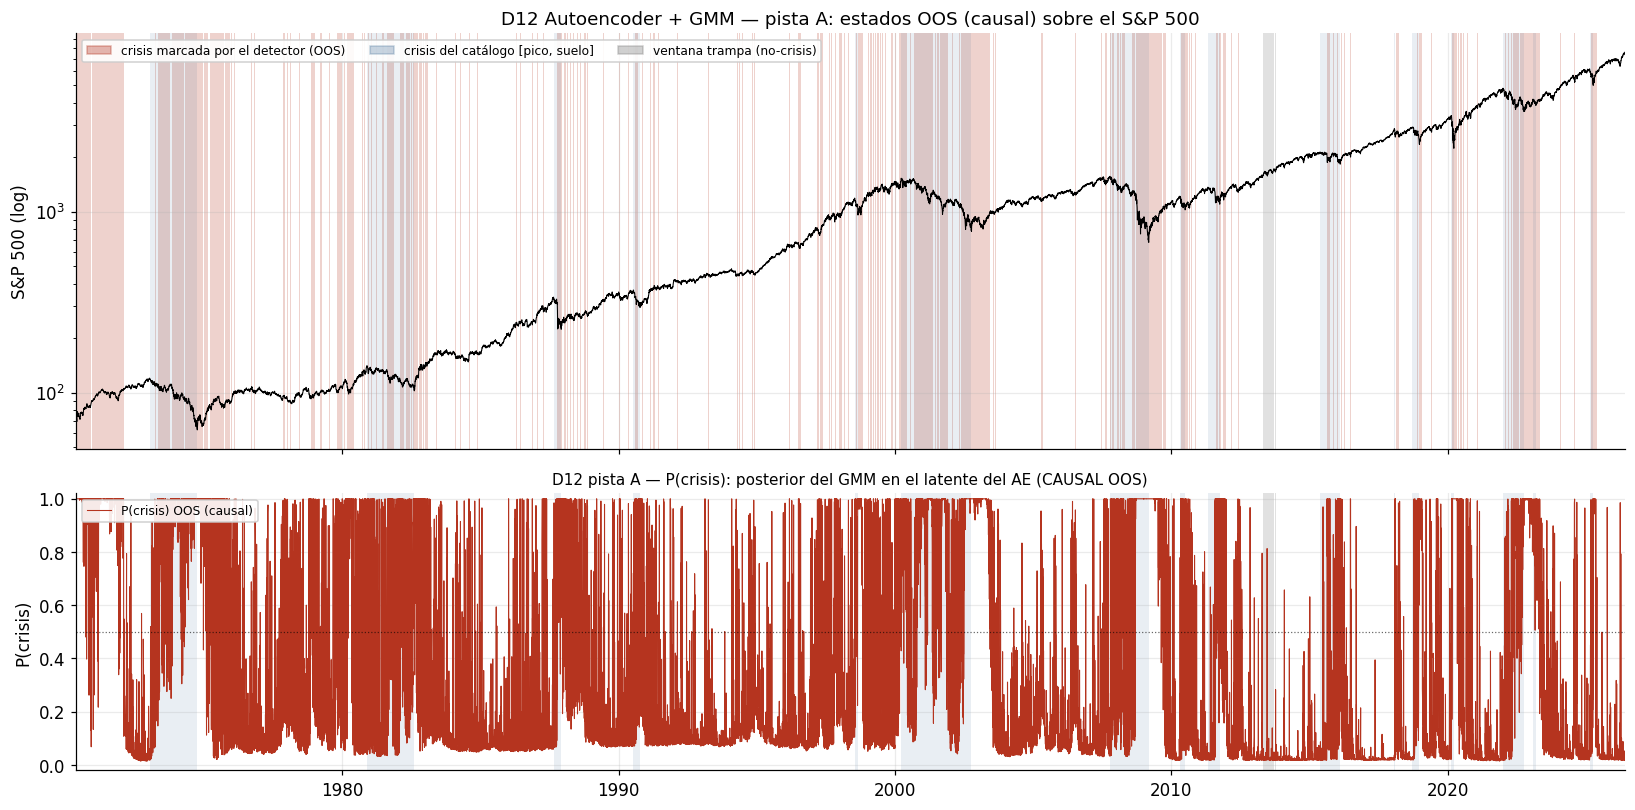

figura -> results/detectores/f7_deep/D12_B_estados_oos.png


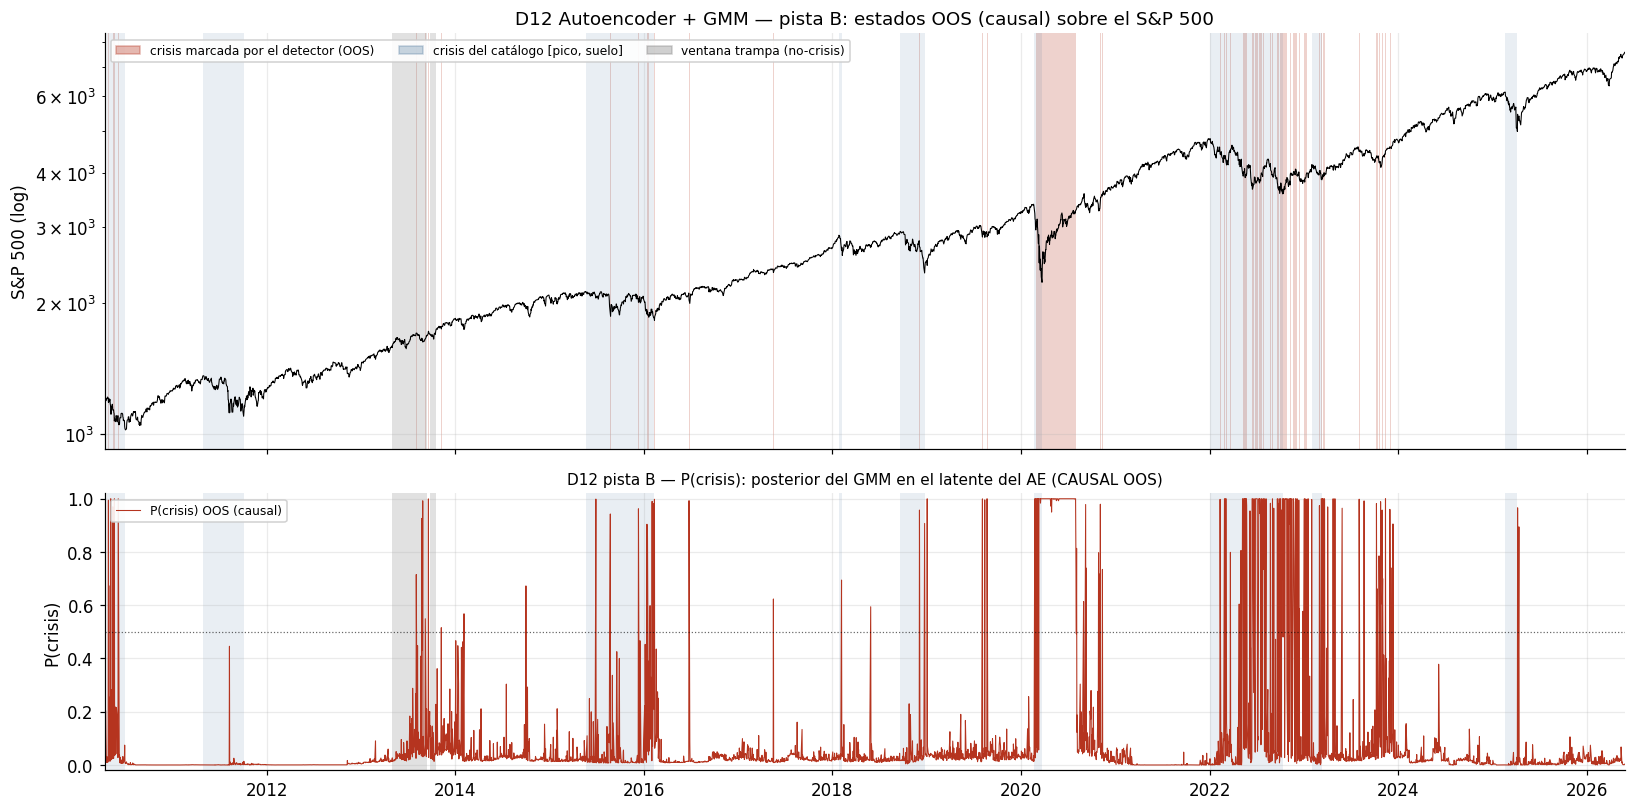

In [7]:
for t in PISTAS:
    figura_estados(t, 'D12', titulo_diag=f'D12 pista {t} — P(crisis): posterior del GMM en el latente del AE (CAUSAL OOS)')

### 4.2 Diagnóstico propio del autoencoder (ilustrativo, no causal)

**¿Entrena bien?** Antes de interpretar un resultado negativo hay que descartar el artefacto
más banal: que la red no aprenda. Se reentrena la misma arquitectura sobre un corte temporal
(la primera parte entrena, el resto valida; estandarización con el tramo de entrenamiento) y
se dibujan ambas pérdidas por época. Es un diagnóstico, no el walk-forward.

Pista A: MSE final train=0.627, validación=0.518 (MSE inicial train=1.031); varianza por feature estandarizada = 1
Pista B: MSE final train=0.676, validación=0.985 (MSE inicial train=1.069); varianza por feature estandarizada = 1


figura -> results/detectores/f7_deep/D12_curva_perdida.png


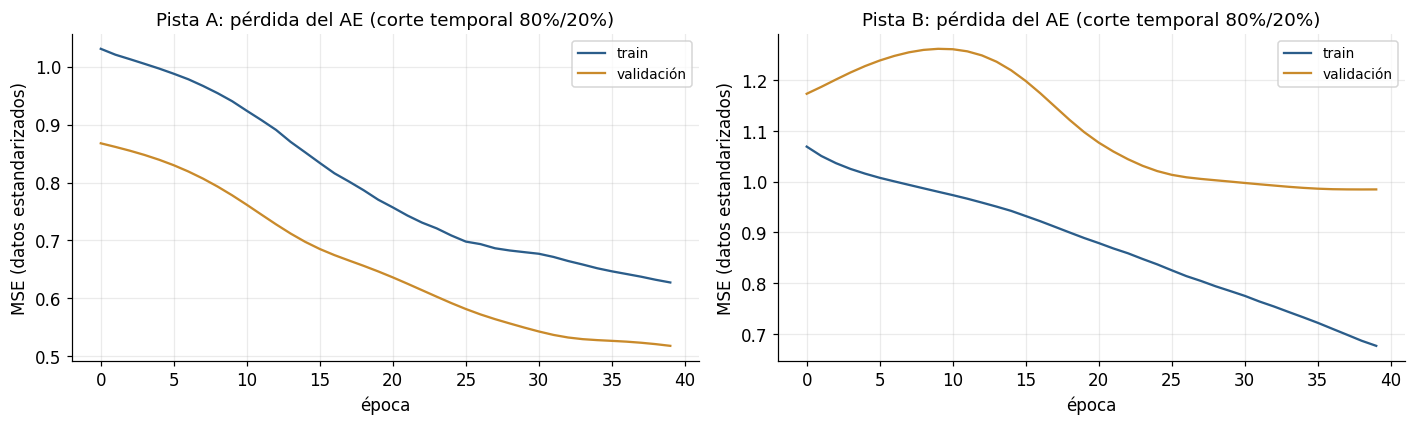

In [8]:
from regimenes.detectores.f7_deep.deep_ae_regime import _Autoencoder, _seed_everything

FRACCION_TRAIN = 0.8
PERDIDA_AE = {}   # MSE final train/validación por pista (veredicto de §6.1)
fig, axes = plt.subplots(1, len(PISTAS), figsize=(13, 4))
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    spec = SPECS[(t, 'D12')]
    det0 = spec.factory()
    panel_t = DATOS[t]
    X = panel_t.loc[common_track_index(t, panel_t), list(spec.features)].to_numpy(dtype=float)
    corte = int(len(X) * FRACCION_TRAIN)
    mu, sd = X[:corte].mean(axis=0), X[:corte].std(axis=0)
    sd[sd < 1e-8] = 1.0
    Xtr = torch.tensor((X[:corte] - mu) / sd, dtype=torch.float32)
    Xva = torch.tensor((X[corte:] - mu) / sd, dtype=torch.float32)
    _seed_everything(det0.random_state)
    ae = _Autoencoder(X.shape[1], det0.hidden, det0.latent_dim, det0.dropout)
    opt = torch.optim.Adam(ae.parameters(), lr=det0.lr, weight_decay=det0.weight_decay)
    perdida = torch.nn.MSELoss()
    hist = []
    for _ in range(det0.epochs):
        ae.train(); opt.zero_grad()
        l_tr = perdida(ae(Xtr), Xtr); l_tr.backward(); opt.step()
        ae.eval()
        with torch.no_grad():
            hist.append((float(l_tr), float(perdida(ae(Xva), Xva))))
    hist = np.array(hist)
    PERDIDA_AE[t] = {'train': float(hist[-1, 0]), 'val': float(hist[-1, 1]), 'inicial': float(hist[0, 0])}
    ax.plot(hist[:, 0], color=viz.C_LONG, label='train'); ax.plot(hist[:, 1], color=viz.C_SHORT, label='validación')
    ax.set_xlabel('época'); ax.set_ylabel('MSE (datos estandarizados)'); ax.legend()
    ax.set_title(f'Pista {t}: pérdida del AE (corte temporal {FRACCION_TRAIN:.0%}/{1 - FRACCION_TRAIN:.0%})')
    print(f'Pista {t}: MSE final train={hist[-1, 0]:.3f}, validación={hist[-1, 1]:.3f} '
          f'(MSE inicial train={hist[0, 0]:.3f}); varianza por feature estandarizada = 1')
fig.tight_layout(); guardar(fig, 'D12_curva_perdida'); plt.show()

**Latente AE frente a proyección PCA y error de reconstrucción.** Se ajustan D12 y el
baseline PCA→GMM **una vez sobre toda la muestra** de la pista (ven el futuro: solo para
mirar la geometría). Si la no linealidad aportara separabilidad, el latente del AE debería
mostrar grupos más limpios que la PCA. El error de reconstrucción se compara dentro y fuera
de las ventanas de crisis del ground-truth (no de los estados del propio modelo). Para el decil
superior de error, la referencia correcta de P(decil superior | crisis) es la probabilidad
incondicional de estar en ese decil (≈ 10 %), no la tasa base de días de crisis; esta última es la
referencia de P(crisis | decil superior). La celda imprime ambos pares.

Pista A: error de reconstrucción mediano dentro/fuera de ventanas de crisis = 1.52; P(decil superior de error | día de crisis) = 16.4% frente a P(decil superior) = 10.0% (lift 1.64); equivalentemente P(crisis | decil superior) = 33.3% frente a la tasa base de días de crisis = 20.2%


figura -> results/detectores/f7_deep/D12_A_latente_ae_vs_pca.png


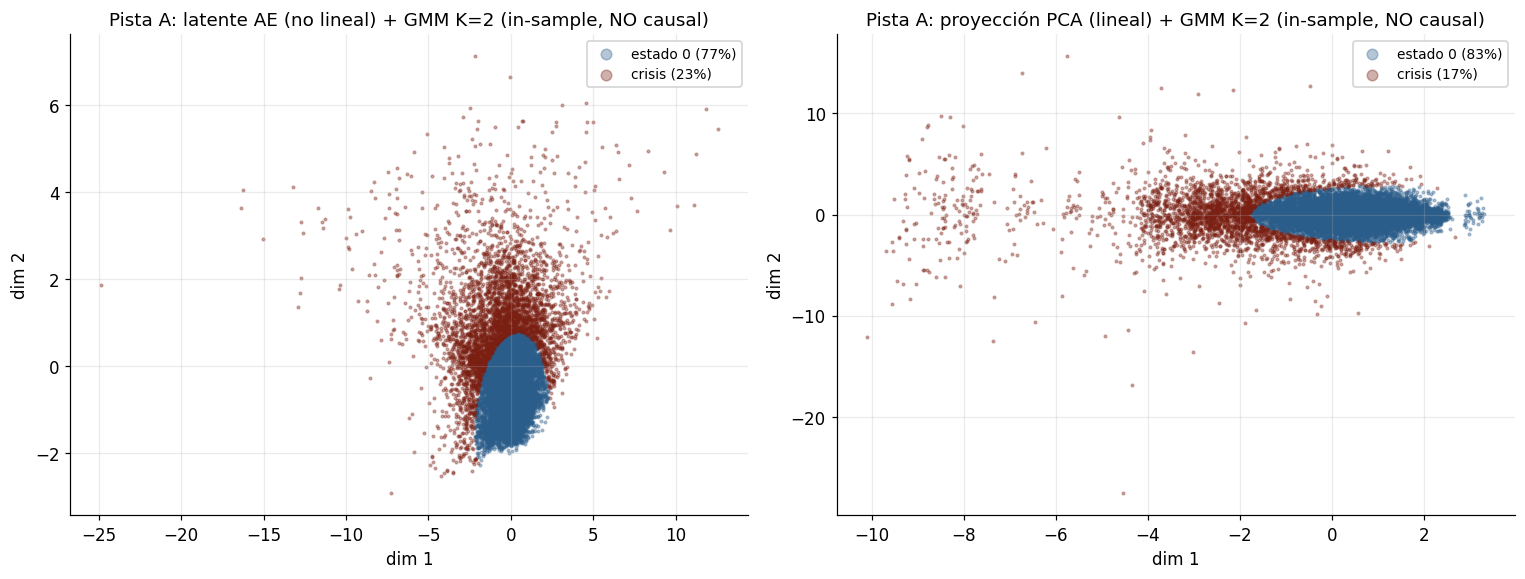

figura -> results/detectores/f7_deep/D12_A_error_reconstruccion.png


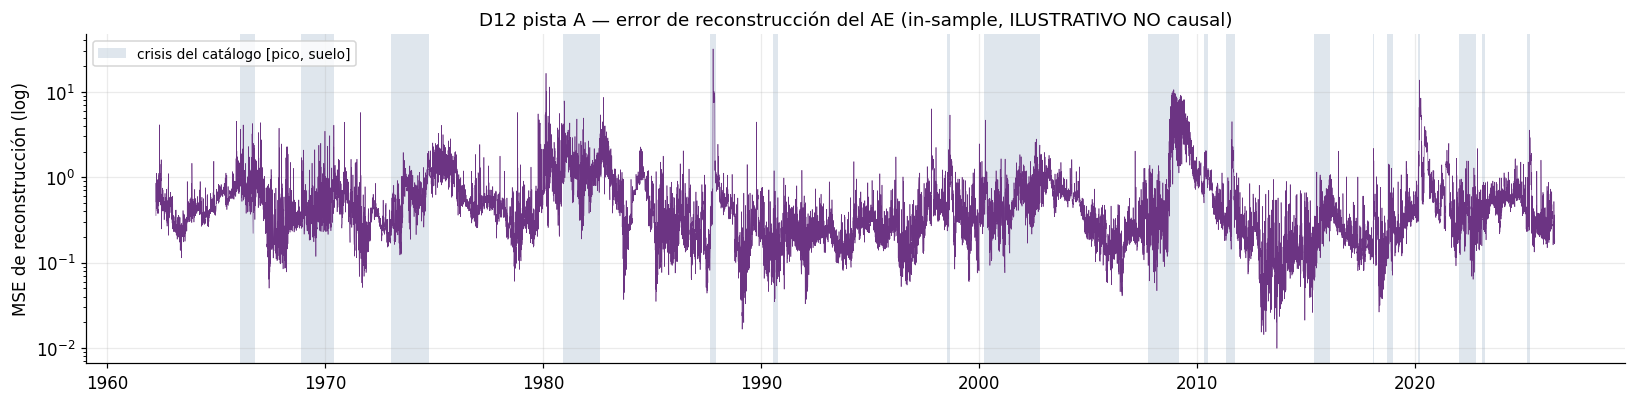

Pista B: error de reconstrucción mediano dentro/fuera de ventanas de crisis = 1.81; P(decil superior de error | día de crisis) = 23.5% frente a P(decil superior) = 10.0% (lift 2.34); equivalentemente P(crisis | decil superior) = 51.5% frente a la tasa base de días de crisis = 22.0%


figura -> results/detectores/f7_deep/D12_B_latente_ae_vs_pca.png


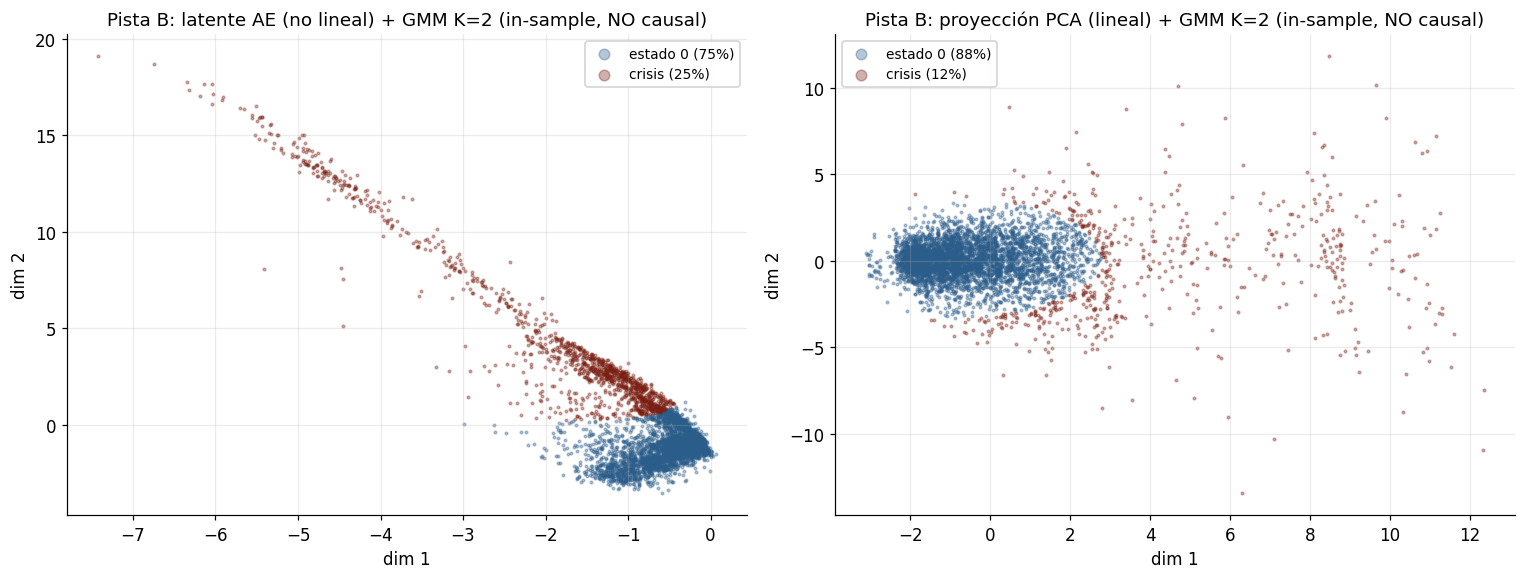

figura -> results/detectores/f7_deep/D12_B_error_reconstruccion.png


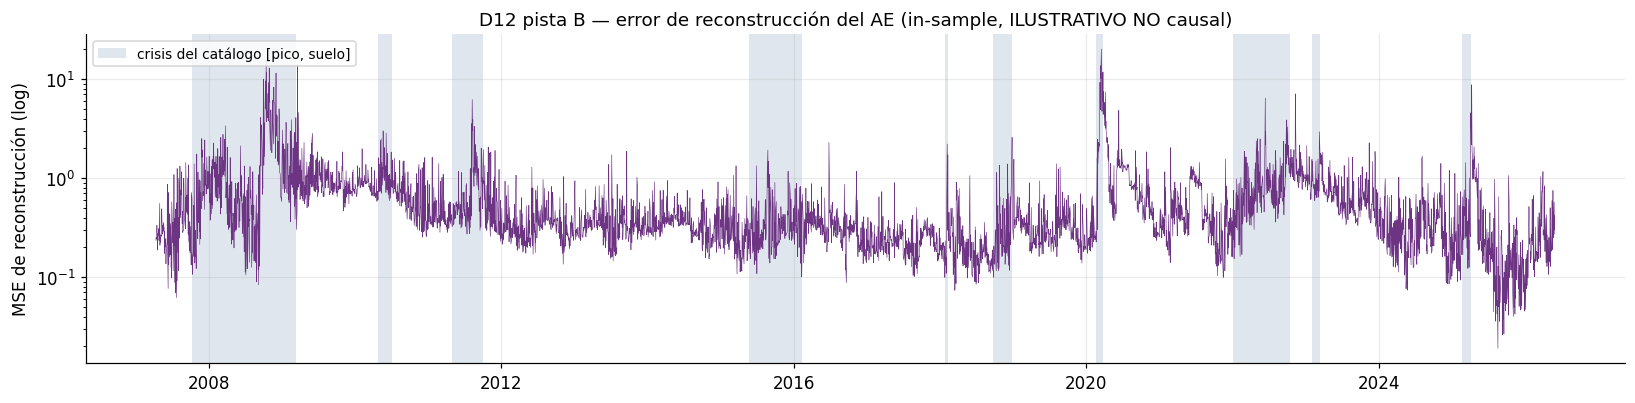

In [9]:
AE_IS = {}
for t in PISTAS:
    configure_evaluation(t)
    spec = SPECS[(t, 'D12')]
    panel_t = DATOS[t]
    X = panel_t.loc[common_track_index(t, panel_t), list(spec.features)]
    mkt = panel_t['SP500_ret'].reindex(X.index)
    ae = spec.factory().fit(X); ae.label_states_economically(X, market_returns=mkt)
    pca = PCAGMMBaseline(n_states=spec.params['n_states'], latent_dim=spec.params['latent_dim'],
                         gmm_n_init=spec.params['gmm_n_init'], random_state=spec.params['random_state']).fit(X)
    pca.label_states_economically(X, market_returns=mkt)
    rec = pd.Series(ae.reconstruction_error(X), index=X.index)
    en_crisis = pd.Series(False, index=X.index)
    for a, b in ev.CRISIS_WINDOWS.values():
        en_crisis |= (X.index >= pd.Timestamp(a)) & (X.index <= pd.Timestamp(b))
    AE_IS[t] = dict(ae=ae, pca=pca, X=X, rec=rec, en_crisis=en_crisis)
    ratio = rec[en_crisis].median() / rec[~en_crisis].median()
    top = rec >= rec.quantile(0.9)
    p_top_crisis, p_top = top[en_crisis].mean(), top.mean()          # P(decil sup. | crisis) vs P(decil sup.)
    p_crisis_top, p_crisis = en_crisis[top].mean(), en_crisis.mean()  # P(crisis | decil sup.) vs P(crisis)
    AE_IS[t].update(p_top_crisis=p_top_crisis, p_top=p_top, ratio=ratio)
    print(f'Pista {t}: error de reconstrucción mediano dentro/fuera de ventanas de crisis = {ratio:.2f}; '
          f'P(decil superior de error | día de crisis) = {p_top_crisis:.1%} frente a P(decil superior) = {p_top:.1%} '
          f'(lift {p_top_crisis / p_top:.2f}); equivalentemente P(crisis | decil superior) = {p_crisis_top:.1%} '
          f'frente a la tasa base de días de crisis = {p_crisis:.1%}')

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5.4))
    for ax, det, titulo in ((axA, ae, 'latente AE (no lineal)'), (axB, pca, 'proyección PCA (lineal)')):
        lat = det._latent(X); est = det.predict(X)
        for s in range(det.n_states):
            m = est == s
            ax.scatter(lat[m, 0], lat[m, 1], s=3, alpha=0.35, color=viz.regime_color(s, det.n_states),
                       label=('crisis' if s == det.crisis_state else f'estado {s}') + f' ({m.mean():.0%})')
        ax.set_title(f'Pista {t}: {titulo} + GMM K={det.n_states} (in-sample, NO causal)')
        ax.set_xlabel('dim 1'); ax.set_ylabel('dim 2'); ax.legend(markerscale=4, framealpha=0.9)
    fig.tight_layout(); guardar(fig, f'D12_{t}_latente_ae_vs_pca'); plt.show()

    fig, ax = plt.subplots(figsize=(15, 3.8))
    ax.plot(rec.index, rec.values, color='#6c3483', lw=0.4)
    ax.set_yscale('log'); sombrear_crisis(ax, alpha=0.15)
    ax.set_ylabel('MSE de reconstrucción (log)'); ax.legend(loc='upper left')
    ax.set_title(f'D12 pista {t} — error de reconstrucción del AE (in-sample, ILUSTRATIVO NO causal)')
    fig.tight_layout(); guardar(fig, f'D12_{t}_error_reconstruccion'); plt.show()

**Parpadeo OOS.** Histograma de duraciones de los episodios de cada estado en el panel OOS
del benchmark: colas concentradas en pocas sesiones = *flickering*.

Pista A: 1351 episodios de crisis; mediana 1 sesiones; 82% duran 2 sesiones o menos
Pista B: 112 episodios de crisis; mediana 1 sesiones; 86% duran 2 sesiones o menos


figura -> results/detectores/f7_deep/D12_duraciones_oos.png


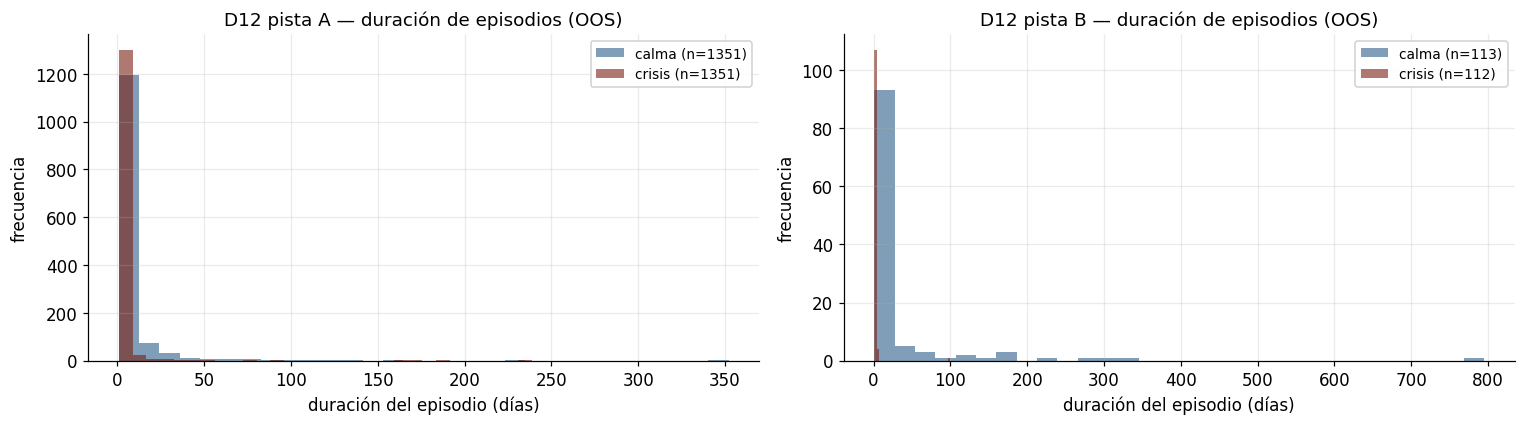

In [10]:
fig, axes = plt.subplots(1, len(PISTAS), figsize=(14, 4))
for ax, t in zip(np.atleast_1d(axes), PISTAS):
    n_states = int(METRICAS.loc[(t, 'D12'), 'n_states'])
    viz.plot_duration_histogram(PANELES[(t, 'D12')]['state'], n_states, ax=ax,
                                title=f'D12 pista {t} — duración de episodios (OOS)')
    dur = viz.episode_durations(PANELES[(t, 'D12')]['state'], n_states)
    cortos = np.mean([d <= 2 for d in dur[n_states - 1]]) if dur[n_states - 1] else np.nan
    print(f'Pista {t}: {len(dur[n_states - 1])} episodios de crisis; '
          f'mediana {np.median(dur[n_states - 1]) if dur[n_states - 1] else np.nan:.0f} sesiones; '
          f'{cortos:.0%} duran 2 sesiones o menos')
fig.tight_layout(); guardar(fig, 'D12_duraciones_oos'); plt.show()

### 4.3 Cobertura por crisis, retardo de confirmación y lead/lag
Misma lectura que en el resto de familias: cobertura con IC90 por *block bootstrap*,
detección por evento (racha mínima, unidad del ranking ADR-003), sesiones desde el pico
hasta el primer día en crisis y lead/lag de la señal sostenida frente al suelo (negativo =
la señal llega antes del suelo). Ojo: `metricas.lead_lag` toma el primer cruce sostenido en una ventana fija antes del suelo; un valor en el tope de esa ventana (saturado) o anterior al pico de la crisis es una alarma ya encendida, no anticipación (ver 10 §4.3 e `inf.clasificar_lead_lag`). Las crisis del entrenamiento inicial no se evalúan.

Pista A: 17 crisis evaluadas OOS | activación en trampas: taper_2013=1.1%, debtceiling_2013=0.0%


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,retardo_confirmacion
crisis,,,,,,,,
bear_1969_70,1968-11-29,1970-05-26,100.0%,100.0%,100.0%,1,-10,0
oil_stagflation_1973,1973-01-11,1974-10-03,78.5%,72.5%,84.7%,1,-249,9
volcker_1980_82,1980-11-28,1982-08-12,48.3%,41.5%,54.2%,1,-246,1
black_monday_1987,1987-08-25,1987-12-04,65.3%,47.2%,83.3%,1,-164,3
gulf_war_sl_1990,1990-07-16,1990-10-11,50.8%,34.9%,68.3%,1,-49,5
ltcm_russia_1998,1998-07-17,1998-08-31,65.6%,50.0%,81.2%,1,-212,2
dotcom_2000_02,2000-03-24,2002-10-09,70.5%,64.9%,76.5%,1,-252,1
gfc_2007_09,2007-10-09,2009-03-09,62.9%,55.3%,70.9%,1,-252,8
flash_crash_euro1_2010,2010-04-23,2010-07-02,42.0%,32.0%,56.0%,1,-252,2


figura -> results/detectores/f7_deep/D12_A_cobertura_crisis.png


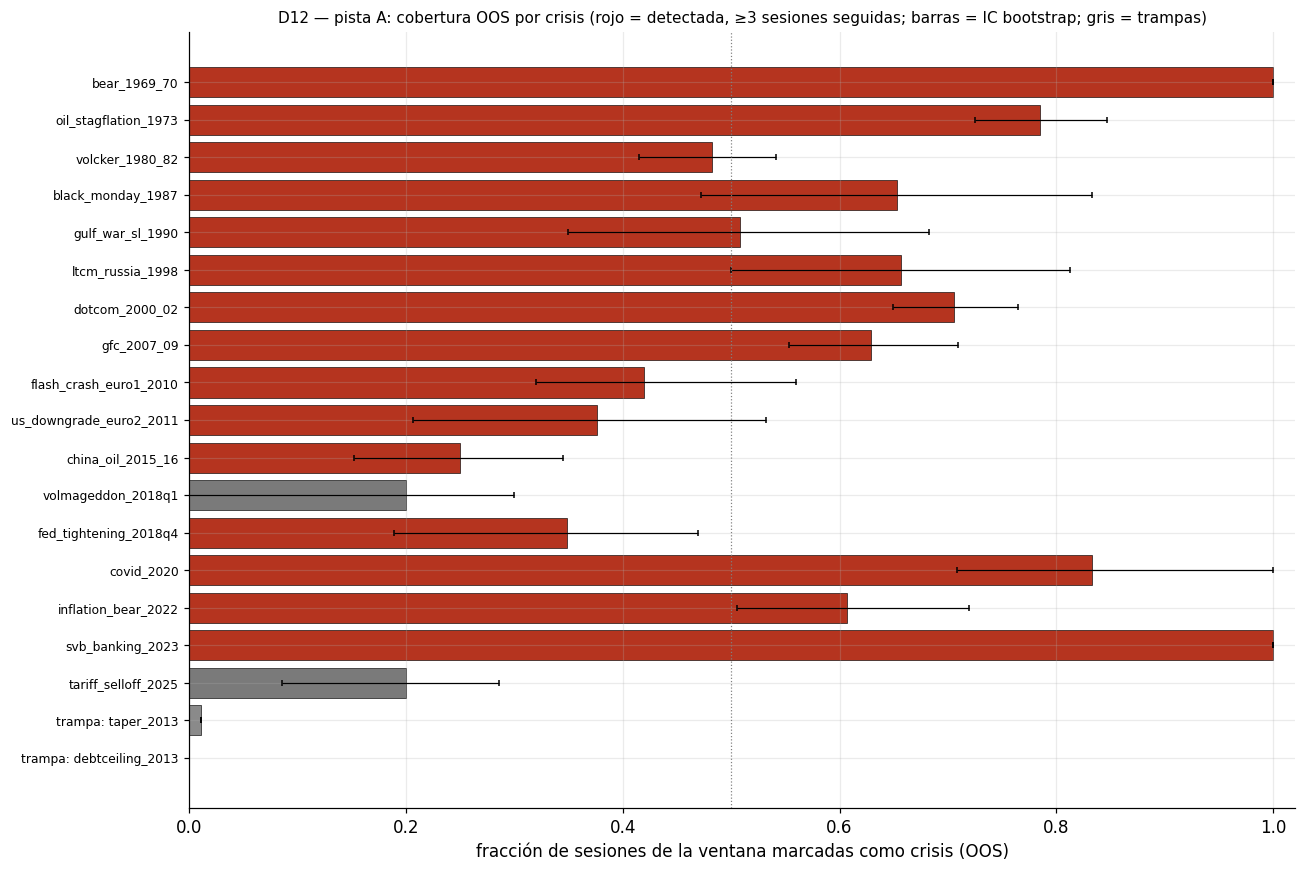

Pista B: 9 crisis evaluadas OOS | activación en trampas: taper_2013=4.2%, debtceiling_2013=0.0%


,pico,suelo,cobertura,ic_lo,ic_hi,detectada,lead_lag_dias,retardo_confirmacion
crisis,,,,,,,,
flash_crash_euro1_2010,2010-04-23,2010-07-02,14.0%,6.0%,26.0%,0,—,2
us_downgrade_euro2_2011,2011-04-29,2011-10-03,0.0%,0.0%,0.0%,0,—,—
china_oil_2015_16,2015-05-21,2016-02-11,5.4%,1.6%,8.2%,0,—,26
volmageddon_2018q1,2018-01-26,2018-02-08,10.0%,0.0%,20.0%,0,—,6
fed_tightening_2018q4,2018-09-20,2018-12-24,3.0%,0.0%,6.1%,0,—,52
covid_2020,2020-02-19,2020-03-23,70.8%,58.3%,91.7%,1,-12,3
inflation_bear_2022,2022-01-03,2022-10-12,29.1%,19.4%,37.8%,1,-108,28
svb_banking_2023,2023-02-02,2023-03-13,11.1%,0.0%,14.8%,0,-211,20
tariff_selloff_2025,2025-02-19,2025-04-08,0.0%,0.0%,0.0%,0,—,—


figura -> results/detectores/f7_deep/D12_B_cobertura_crisis.png


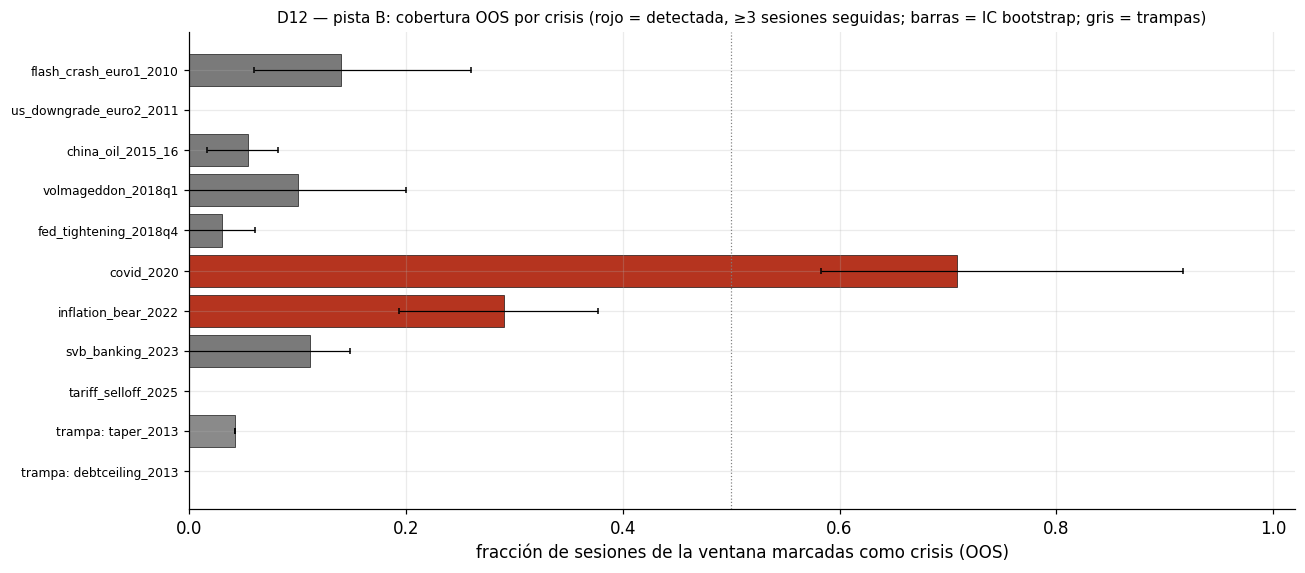

In [11]:
TABLAS_CRISIS = {}
for t in PISTAS:
    tab, trampas = tabla_crisis(t, 'D12')
    tab = tab.join(retardo_confirmacion(t, 'D12'))
    TABLAS_CRISIS[t] = (tab, trampas)
    print(f'Pista {t}: {len(tab)} crisis evaluadas OOS | activación en trampas: '
          + ', '.join(f'{k}={v:.1%}' for k, v in trampas.items()))
    display(tab.style.format({'cobertura': '{:.1%}', 'ic_lo': '{:.1%}', 'ic_hi': '{:.1%}',
                              'detectada': '{:.0f}', 'lead_lag_dias': '{:.0f}',
                              'retardo_confirmacion': '{:.0f}'}, na_rep='—'))
    figura_cobertura(t, 'D12')

### 4.4 Métricas y puesto en el ranking de detección ADR-003
`score_deteccion` es la F1 entre recall por evento y precisión diaria; el nivel
(`elegible`, `precision_no_supera_azar`, `parpadeo`, `degenerado`) se ordena antes que el
score, de modo que un detector que parpadea queda por detrás de los elegibles aunque su F1
sea mayor.

In [12]:
RESUMEN = pd.DataFrame({f'D12 pista {t}': resumen_metricas(t, 'D12') for t in PISTAS})
display(resumen_ranking(DETECTORES).round(4))
display(RESUMEN)
PARAMS_RANK = rk.DETECTION_DEFAULTS
for t in PISTAS:
    m = METRICAS.loc[(t, 'D12')]
    print(f"Pista {t}: duración media de régimen {m['mean_regime_duration']:.1f} (filtro >= {PARAMS_RANK['min_mean_duration']}), "
          f"racha media de crisis {m['det_mean_crisis_run']:.1f} (filtro >= {PARAMS_RANK['min_crisis_run']}), "
          f"lift {m['det_lift_precision']:.2f} (debe superar {PARAMS_RANK['lift_min']}) -> nivel {RANK_FAM.loc[(t, 'D12'), 'nivel_etiqueta']}")

,,puesto_deteccion,de,nivel_etiqueta,score_deteccion,det_event_recall,det_n_detectados,det_n_eventos,det_precision,det_lift_precision,det_base_rate,det_marked_rate,det_mean_crisis_run,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds
pista,id,,,,,,,,,,,,,,,,,,,
A,D12,6,12,elegible,0.5453,0.8824,15,17,0.3946,2.0347,0.1939,0.2944,3.0799,0.5679,0.6054,0.0053,0.1911,5.2306,0.9948,351.5906
B,D12,12,12,parpadeo,0.2742,0.2222,2,9,0.3579,2.0725,0.1727,0.0668,2.4196,0.1594,0.6421,0.0211,0.0552,18.0400,0.9975,55.0715


,D12 pista A,D12 pista B
n_oos,14133,4059
oos_start,1970-05-12,2010-04-12
oos_end,2026-05-29,2026-05-29
det_event_recall,0.882353,0.222222
det_n_detectados,15,2
det_n_eventos,17,9
det_precision,0.394617,0.357934
det_lift_precision,2.034702,2.072543
det_marked_rate,0.294417,0.066765
det_day_recall,0.599051,0.138374


Pista A: duración media de régimen 5.2 (filtro >= 5.0), racha media de crisis 3.1 (filtro >= 3.0), lift 2.03 (debe superar 1.0) -> nivel elegible
Pista B: duración media de régimen 18.0 (filtro >= 5.0), racha media de crisis 2.4 (filtro >= 3.0), lift 2.07 (debe superar 1.0) -> nivel parpadeo


<a id="s5"></a>
## 5. Comparación intra-familia

F7 tiene un único detector en el benchmark; la comparación que responde a la pregunta de la
familia es el **contraste ablativo** AE→GMM frente a **PCA→GMM** con la misma dimensión
latente, el mismo $K$, la misma semilla y el **mismo protocolo** que `run_one` (índice común,
train inicial, `step`, `market_returns`, métricas `det_*`), situado hipotéticamente en el
ranking de su pista. Como referencia sin reductor se añade D03 (GMM sobre las features
crudas, familia F2; ojo: con su propio $K$). La comparación entre pistas pone a prueba el
argumento del estado del arte de que "con más datos" el deep podría justificarse: la pista A
tiene mucha más historia. `EJECUTAR_ABLACION = False` omite el baseline; su panel se guarda como caché
local en `results/detectores/f7_deep/` (sin huella: `FORZAR_ABLACION = True` si cambia algo).

In [13]:
def evaluar_variante(t, fabrica, features, *, step, expanding, nombre, recalcular=False):
    """Walk-forward causal de una variante NO registrada con el MISMO protocolo que run_one
    (índice común de la pista, train inicial, step, market_returns, evaluate + det_*).
    El panel OOS se guarda como caché local en results/detectores/<familia>/ (sin huella:
    pon recalcular=True si cambia el código o los datos; label_stability queda NaN al leerlo)."""
    configure_evaluation(t)
    panel_t = DATOS[t]
    X = panel_t.loc[common_track_index(t, panel_t), list(features)]
    mkt = panel_t['SP500_ret'].reindex(X.index)
    n_train = DEFAULT_TRAIN_DAYS[t]
    ruta = FIG_DIR / f'variante_{nombre}_{t}.parquet'
    if ruta.is_file() and not recalcular:
        wf = pd.read_parquet(ruta)
    else:
        wf = ev.walk_forward(fabrica, X, market_returns=mkt, train_size=n_train, min_train=n_train,
                             step=step, expanding=expanding)
        copia = wf.copy(); copia.attrs = {}
        copia.to_parquet(ruta)
    final = fabrica()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        final.fit(X)
    final.label_states_economically(X, market_returns=mkt)
    fila = ev.results_table([ev.evaluate(final, wf, market_returns=mkt, X_full=X)])
    for k, v in detection_summary(wf['state'].eq(final.crisis_state), dict(ev.CRISIS_WINDOWS)).items():
        fila[k] = v
    fila.insert(0, 'id', nombre)
    fila.insert(0, 'pista', t)
    fila = rk.add_comparison_metrics(fila)
    return wf, fila.iloc[0]


def puesto_hipotetico(t, fila):
    """Puesto que ocuparía la variante si se añadiera al ranking ADR-003 de su pista."""
    if not MATRIZ_COMPLETA:
        return np.nan, 'n/d (matriz 2x12 no vigente)'
    base = METRICAS_TODAS[METRICAS_TODAS['pista'].eq(t)]
    r = rk.rank_detection(pd.concat([base, pd.DataFrame([fila.to_dict()])], ignore_index=True),
                          output_dir=OUTPUT_DIR)
    r = r.set_index('id').loc[fila['id']]
    return int(r['puesto_deteccion']), r['nivel_etiqueta']


COLS_CONTRASTE = ['det_event_recall', 'det_precision', 'det_lift_precision', 'det_marked_rate',
                  'det_mean_crisis_run', 'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation',
                  'switching_rate', 'mean_regime_duration']

In [14]:
EJECUTAR_ABLACION = True
FORZAR_ABLACION = False
filas = []
PANELES_VAR = {}
for t in PISTAS:
    spec = SPECS[(t, 'D12')]
    fila_of = METRICAS.loc[(t, 'D12')].reindex(COLS_CONTRASTE).to_dict()
    fila_of.update({'pista': t, 'variante': 'AE -> GMM (D12)', 'K': int(METRICAS.loc[(t, 'D12'), 'n_states']),
                    'score_deteccion': RANK_FAM.loc[(t, 'D12'), 'score_deteccion'],
                    'puesto': f"{int(RANK_FAM.loc[(t, 'D12'), 'puesto_deteccion'])} de {N_RANK[t]}",
                    'nivel': RANK_FAM.loc[(t, 'D12'), 'nivel_etiqueta']})
    filas.append(fila_of)
    if EJECUTAR_ABLACION:
        kw = dict(n_states=spec.params['n_states'], latent_dim=spec.params['latent_dim'],
                  gmm_n_init=spec.params['gmm_n_init'], random_state=spec.params['random_state'])
        wf_p, fila_p = evaluar_variante(t, lambda kw=kw: PCAGMMBaseline(**kw), spec.features,
                                        step=spec.step, expanding=spec.expanding,
                                        nombre='D12_pca', recalcular=FORZAR_ABLACION)
        PANELES_VAR[t] = wf_p
        puesto, nivel = puesto_hipotetico(t, fila_p)
        d = fila_p.reindex(COLS_CONTRASTE).to_dict()
        d.update({'pista': t, 'variante': 'PCA -> GMM (ablación)', 'K': kw['n_states'],
                  'score_deteccion': rk.detection_score(fila_p['det_precision'], fila_p['det_event_recall']),
                  'puesto': f'{puesto} de {N_RANK[t] + 1} (hipotético)' if puesto == puesto else nivel,
                  'nivel': nivel})
        filas.append(d)
    ref = METRICAS_TODAS[(METRICAS_TODAS['pista'] == t) & (METRICAS_TODAS['id'] == 'D03')]
    if len(ref) and (t, 'D03') in RANKING.set_index(['pista', 'id']).index:
        r03 = RANKING.set_index(['pista', 'id']).loc[(t, 'D03')]
        d = rk.add_comparison_metrics(ref).iloc[0].reindex(COLS_CONTRASTE).to_dict()
        d.update({'pista': t, 'variante': 'GMM sin reductor (D03, F2)', 'K': int(ref['n_states'].iloc[0]),
                  'score_deteccion': r03['score_deteccion'],
                  'puesto': f"{int(r03['puesto_deteccion'])} de {N_RANK[t]}", 'nivel': r03['nivel_etiqueta']})
        filas.append(d)
CONTRASTE = pd.DataFrame(filas).set_index(['pista', 'variante'])
display(CONTRASTE.style.format(precision=3))

figura -> results/detectores/f7_deep/F7_comparativa_ae_vs_pca_estados.png


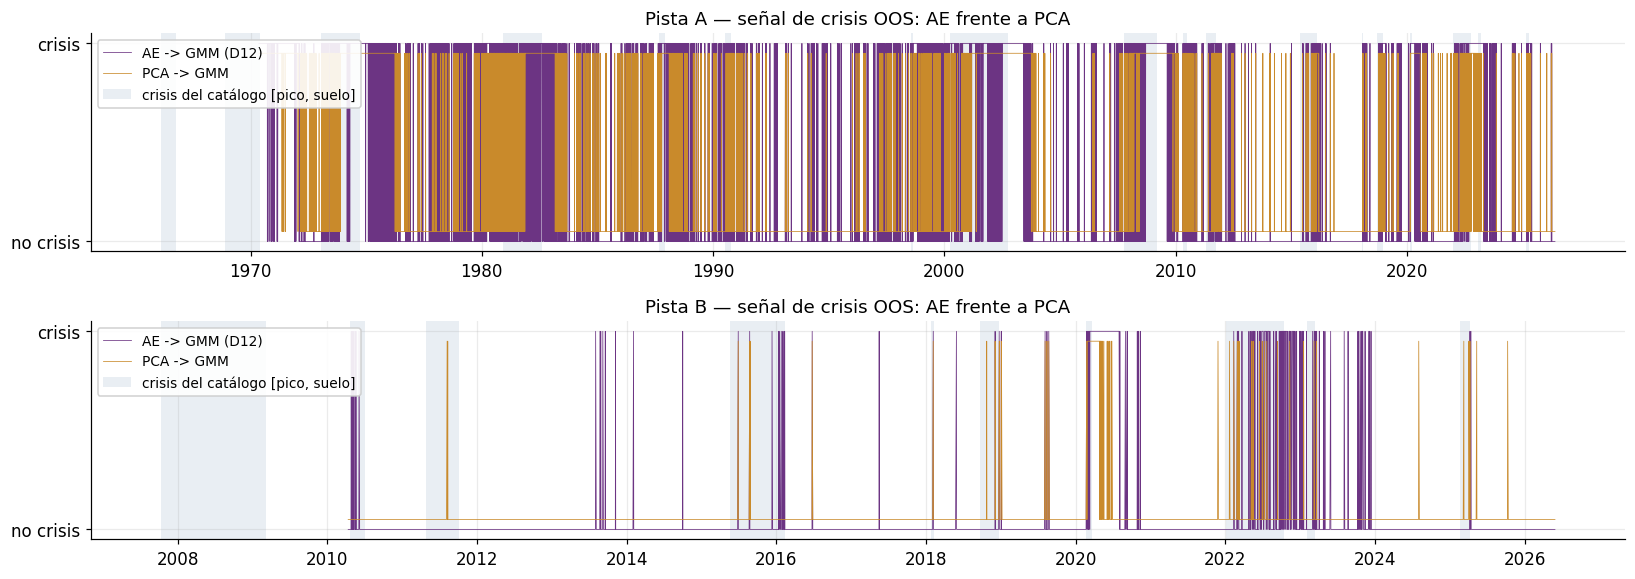

figura -> results/detectores/f7_deep/F7_comparativa_contraste_ablativo.png


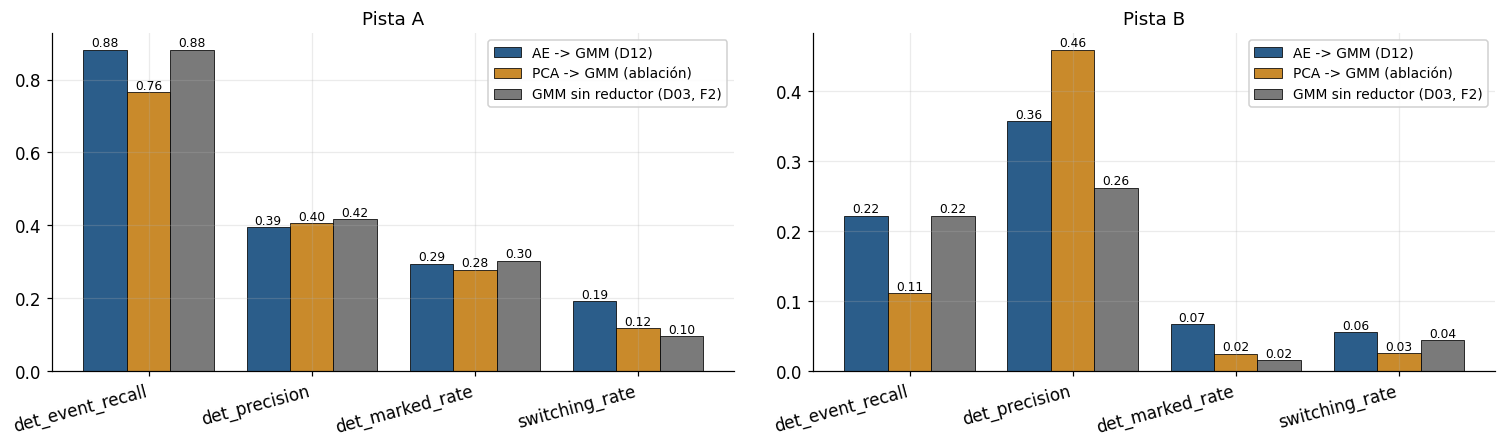

In [15]:
if EJECUTAR_ABLACION:
    fig, axes = plt.subplots(len(PISTAS), 1, figsize=(15, 2.4 * len(PISTAS) + 0.6))
    for ax, t in zip(np.atleast_1d(axes), PISTAS):
        configure_evaluation(t)
        cs = int(METRICAS.loc[(t, 'D12'), 'n_states']) - 1
        ae_c = PANELES[(t, 'D12')]['state'].eq(cs).astype(int)
        pca_c = PANELES_VAR[t]['state'].eq(cs).astype(int)  # mismo K -> mismo índice de crisis
        ax.plot(ae_c.index, ae_c.values, color='#6c3483', lw=0.5, label='AE -> GMM (D12)')
        ax.plot(pca_c.index, pca_c.values * 0.9 + 0.05, color=viz.C_SHORT, lw=0.5, label='PCA -> GMM')
        sombrear_crisis(ax); ax.set_yticks([0, 1], ['no crisis', 'crisis'])
        ax.set_title(f'Pista {t} — señal de crisis OOS: AE frente a PCA'); ax.legend(loc='upper left', framealpha=0.9)
    fig.tight_layout(); guardar(fig, 'F7_comparativa_ae_vs_pca_estados'); plt.show()

    metricas_barras = ['det_event_recall', 'det_precision', 'det_marked_rate', 'switching_rate']
    fig, axes = plt.subplots(1, len(PISTAS), figsize=(14, 4.2))
    for ax, t in zip(np.atleast_1d(axes), PISTAS):
        part = CONTRASTE.loc[t]
        viz.plot_grouped_bars(metricas_barras, {v: part.loc[v, metricas_barras].astype(float).tolist() for v in part.index},
                              ax=ax, title=f'Pista {t}', value_labels=True, rotation=15)
    fig.tight_layout(); guardar(fig, 'F7_comparativa_contraste_ablativo'); plt.show()

In [16]:
ENTRE_PISTAS = pd.DataFrame({t: {
    'OOS': f"{METRICAS.loc[(t, 'D12'), 'oos_start']} -> {METRICAS.loc[(t, 'D12'), 'oos_end']}",
    'sesiones de train inicial': DEFAULT_TRAIN_DAYS[t],
    'n_features': len(SPECS[(t, 'D12')].features),
    'crisis evaluadas': len(TABLAS_CRISIS[t][0]),
    'recall por evento': METRICAS.loc[(t, 'D12'), 'det_event_recall'],
    'precisión': METRICAS.loc[(t, 'D12'), 'det_precision'],
    'switching': METRICAS.loc[(t, 'D12'), 'switching_rate'],
    'duración media régimen': METRICAS.loc[(t, 'D12'), 'mean_regime_duration'],
    'puesto ADR-003': f"{int(RANK_FAM.loc[(t, 'D12'), 'puesto_deteccion'])} de {N_RANK[t]} ({RANK_FAM.loc[(t, 'D12'), 'nivel_etiqueta']})",
} for t in PISTAS})
display(ENTRE_PISTAS)

,A,B
OOS,1970-05-12 -> 2026-05-29,2010-04-12 -> 2026-05-29
sesiones de train inicial,2016,756
n_features,9,14
crisis evaluadas,17,9
recall por evento,0.882353,0.222222
precisión,0.394617,0.357934
switching,0.191113,0.055186
duración media régimen,5.23057,18.04
puesto ADR-003,6 de 12 (elegible),12 de 12 (parpadeo)


<a id="s6"></a>
## 6. Hallazgos de la Capa 1 (v1) y qué se mantiene / cambia en v2

**Lo que concluyó la Capa 1** (ficha `docs/detectores/D12_deep_ae_regime.md`, notebook
`capa1-final:capa1_exploracion/notebooks/12_deep_ae_regime.ipynb`, tag git `capa1-final`), con la hipótesis del CHECKPOINT 2
*"contraste ablativo honesto; con pocas crisis el resultado negativo es aceptable"*:

- **El AE entrenaba bien** (curvas de train y validación juntas): el negativo no era un
  artefacto de ajuste.
- **Resultado negativo**: frente a PCA→GMM con la misma dimensión y $K$, el AE **añadía
  parpadeo y falsas alarmas sin ganar cobertura**; el latente no lineal no separaba mejor que
  la proyección lineal y el error de reconstrucción discriminaba poco las crisis.
- **Causalidad**: el criterio correcto para redes es la invariancia de los **estados** al
  ocultar el futuro, no la igualdad exacta del latente en `float32`.
- **Ventana corta**: con las features del panel de la Capa 1 el OOS solo contenía las crisis
  recientes; las grandes crisis anteriores caían en el entrenamiento.
- **Lectura metodológica**: con estos datos un reductor lineal es preferible; el deep solo
  se justificaría con muchos más datos (intradía) o más historia.

**Qué cambia en v2.** Mismo código (congelado); cambian la configuración y el juez: $K$ y
el conjunto de features se toman del registro v2 (núcleo `CORE_A` en la pista A y
`CORE_B` en la B), la pista A ofrece precisamente **mucha más historia** (la condición bajo
la que el estado del arte admitía el deep), el índice OOS es común a todos los detectores y
el ranking es por detección de eventos con filtros de persistencia (ADR-003), que penalizan
explícitamente el parpadeo. La celda siguiente enfrenta las métricas archivadas de la Capa 1
(AE y PCA) con las de v2.

In [17]:
V1_CSV = rutas.DOCS / 'historia' / 'capa1' / 'resultados' / 'metrics_12_deep_ae_regime.csv'
cols = ['n_states', 'ventana_eval', 'n_oos', 'false_alarm_rate', 'switching_rate', 'mean_regime_duration',
        'label_stability']
if V1_CSV.is_file():
    v1 = pd.read_csv(V1_CSV).set_index('detector')
    comp = {f'v1 {k}': v1.loc[k].reindex(cols) for k in v1.index}
    for t in PISTAS:
        comp[f'v2 {t} AE (D12)'] = METRICAS.loc[(t, 'D12')].reindex(cols)
    display(pd.DataFrame(comp))
    if {'deep_ae_regime', 'pca_gmm_baseline'} <= set(v1.index):
        a, p = v1.loc['deep_ae_regime'], v1.loc['pca_gmm_baseline']
        print(f"v1: AE/PCA switching = {a['switching_rate'] / p['switching_rate']:.1f}x ; "
              f"false_alarm_rate AE={a['false_alarm_rate']:.2f} vs PCA={p['false_alarm_rate']:.2f} ; "
              f"duración media AE={a['mean_regime_duration']:.1f} vs PCA={p['mean_regime_duration']:.1f} sesiones")
    if EJECUTAR_ABLACION:
        for t in PISTAS:
            a, p = CONTRASTE.loc[(t, 'AE -> GMM (D12)')], CONTRASTE.loc[(t, 'PCA -> GMM (ablación)')]
            print(f"v2 pista {t}: AE/PCA switching = {a['switching_rate'] / p['switching_rate']:.1f}x ; "
                  f"false_alarm_rate AE={a['false_alarm_rate']:.2f} vs PCA={p['false_alarm_rate']:.2f} ; "
                  f"F1 detección AE={a['score_deteccion']:.3f} vs PCA={p['score_deteccion']:.3f}")
else:
    print(f'No se encuentra {rel(V1_CSV)}; las métricas v1 están en el tag capa1-final.')
print('Configuración v2 (registro):', {t: dict(SPECS[(t, "D12")].params) for t in PISTAS})
print('n_features v2:', {t: len(SPECS[(t, "D12")].features) for t in PISTAS})

,v1 deep_ae_regime,v1 pca_gmm_baseline,v2 A AE (D12),v2 B AE (D12)
n_states,3,3,2,2
ventana_eval,2015-09-15→2026-06-12 (n=2649),2015-09-15→2026-06-12 (n=2649),1970-05-12→2026-05-29 (n=14133),2010-04-12→2026-05-29 (n=4059)
n_oos,2649,2649,14133,4059
false_alarm_rate,0.603306,0.135135,0.605383,0.642066
switching_rate,0.287278,0.091355,0.191113,0.055186
mean_regime_duration,3.476378,10.901235,5.23057,18.04
label_stability,0.964475,0.996977,0.994827,0.997533


v1: AE/PCA switching = 3.1x ; false_alarm_rate AE=0.60 vs PCA=0.14 ; duración media AE=3.5 vs PCA=10.9 sesiones
v2 pista A: AE/PCA switching = 1.6x ; false_alarm_rate AE=0.61 vs PCA=0.60 ; F1 detección AE=0.545 vs PCA=0.529
v2 pista B: AE/PCA switching = 2.2x ; false_alarm_rate AE=0.64 vs PCA=0.54 ; F1 detección AE=0.274 vs PCA=0.179
Configuración v2 (registro): {'A': {'n_states': 2, 'latent_dim': 2, 'hidden': 8, 'epochs': 40, 'gmm_n_init': 3, 'random_state': 42}, 'B': {'n_states': 2, 'latent_dim': 2, 'hidden': 8, 'epochs': 40, 'gmm_n_init': 3, 'random_state': 42}}
n_features v2: {'A': 9, 'B': 14}


<a id="s6-cp2"></a>
### 6.1 Hipótesis del CHECKPOINT 2 y veredicto (v1 → v2)

**Hipótesis** (ficha `docs/detectores/D12_deep_ae_regime.md`, apartado «Hipótesis del CHECKPOINT
2 para D12 — veredicto»): *«Contraste ablativo honesto; con ~4 crisis el resultado negativo es
aceptable; el deep solo se justificaría con más datos.»*

**Veredicto v1: se cumple exactamente.** El AE no aportaba sobre PCA: añadía parpadeo y falsas
alarmas sin ganar cobertura, entrenaba bien (el negativo no era un artefacto de ajuste) y el
error de reconstrucción discriminaba poco las crisis.

**Qué dice v2.** La celda siguiente contrasta cada afirmación v1 con las salidas de este
notebook:

1. **«El AE entrenaba bien»**: MSE final de train frente a validación en el corte temporal de
   §4.2 (con datos estandarizados, un MSE de validación cercano a 1 equivale a no reconstruir
   mejor que la media).
2. **«Añadía parpadeo»**: *switching* AE frente a PCA (ablación de §5).
3. **«Y falsas alarmas»**: `false_alarm_rate` AE frente a PCA.
4. **«Sin ganar detección»**: F1 de detección ADR-003 AE frente a PCA.
5. **«El error de reconstrucción discriminaba poco»**: lift de P(decil superior | crisis) sobre
   P(decil superior) (§4.2).
6. **Pista A = más historia**, la condición en la que el estado del arte admitía el deep.

In [18]:
# Veredicto v2 de cada afirmación v1 (cifras: PERDIDA_AE y AE_IS de §4.2, CONTRASTE de §5, RANK_FAM).
lineas = []
for t in PISTAS:
    partes = []
    if t in PERDIDA_AE:
        p = PERDIDA_AE[t]
        partes.append(f"(1) MSE train {p['train']:.3f} vs validación {p['val']:.3f} → "
                      + ('entrena y generaliza' if p['val'] <= 1.1 * p['train'] else
                         'brecha de generalización: la validación queda muy por encima del train'
                         + (' y cerca de la varianza (≈ 1)' if p['val'] > 0.9 else '')))
    if EJECUTAR_ABLACION:
        a, q = CONTRASTE.loc[(t, 'AE -> GMM (D12)')], CONTRASTE.loc[(t, 'PCA -> GMM (ablación)')]
        partes.append(f"(2) switching AE {a['switching_rate']:.3f} vs PCA {q['switching_rate']:.3f} → "
                      + ('sigue añadiendo parpadeo' if a['switching_rate'] > q['switching_rate'] else 'ya no parpadea más'))
        partes.append(f"(3) false_alarm_rate AE {a['false_alarm_rate']:.2f} vs PCA {q['false_alarm_rate']:.2f} → "
                      + ('más falsas alarmas' if a['false_alarm_rate'] > q['false_alarm_rate'] + 0.02
                         else 'falsas alarmas similares o menores'))
        partes.append(f"(4) F1 de detección AE {a['score_deteccion']:.3f} vs PCA {q['score_deteccion']:.3f}; recall por evento "
                      f"{a['det_event_recall']:.2f} vs {q['det_event_recall']:.2f} → "
                      + ('«sin ganar detección» NO se sostiene: el AE detecta mejor que la PCA'
                         if a['score_deteccion'] > q['score_deteccion'] else '«sin ganar detección» se sostiene'))
    if t in AE_IS and 'p_top_crisis' in AE_IS[t]:
        e = AE_IS[t]
        lift = e['p_top_crisis'] / e['p_top']
        partes.append(f"(5) lift del decil superior de error en crisis {lift:.2f} → "
                      + ('discrimina las crisis mejor que el azar' if lift > 1.2 else 'discrimina poco'))
    r = RANK_FAM.loc[(t, 'D12')]
    partes.append(f"puesto ADR-003 {int(r['puesto_deteccion'])} de {N_RANK[t]} (`{r['nivel_etiqueta']}`)")
    lineas.append(f"- **Pista {t}.** " + '; '.join(partes) + '.')
if EJECUTAR_ABLACION:
    gana = [t for t in PISTAS if CONTRASTE.loc[(t, 'AE -> GMM (D12)'), 'score_deteccion']
            > CONTRASTE.loc[(t, 'PCA -> GMM (ablación)'), 'score_deteccion']]
    lineas.append('- **Veredicto global v2:** '
                  + ('el resultado negativo v1 («el AE no mejora a la PCA») **no se reproduce en detección**: el AE supera a '
                     f"la PCA en F1 en {', '.join(gana)}, aunque sigue parpadeando más. La conclusión metodológica pasa de "
                     '«la PCA es preferible» a «la no linealidad compra algo de detección a cambio de estabilidad»; '
                     'el AE sigue siendo exploratorio' if gana else
                     'el resultado negativo v1 se reproduce: el AE no mejora a la PCA en ninguna pista') + '.')
display(Markdown('\n'.join(lineas)))

- **Pista A.** (1) MSE train 0.627 vs validación 0.518 → entrena y generaliza; (2) switching AE 0.191 vs PCA 0.118 → sigue añadiendo parpadeo; (3) false_alarm_rate AE 0.61 vs PCA 0.60 → falsas alarmas similares o menores; (4) F1 de detección AE 0.545 vs PCA 0.529; recall por evento 0.88 vs 0.76 → «sin ganar detección» NO se sostiene: el AE detecta mejor que la PCA; (5) lift del decil superior de error en crisis 1.64 → discrimina las crisis mejor que el azar; puesto ADR-003 6 de 12 (`elegible`).
- **Pista B.** (1) MSE train 0.676 vs validación 0.985 → brecha de generalización: la validación queda muy por encima del train y cerca de la varianza (≈ 1); (2) switching AE 0.055 vs PCA 0.025 → sigue añadiendo parpadeo; (3) false_alarm_rate AE 0.64 vs PCA 0.54 → más falsas alarmas; (4) F1 de detección AE 0.274 vs PCA 0.179; recall por evento 0.22 vs 0.11 → «sin ganar detección» NO se sostiene: el AE detecta mejor que la PCA; (5) lift del decil superior de error en crisis 2.34 → discrimina las crisis mejor que el azar; puesto ADR-003 12 de 12 (`parpadeo`).
- **Veredicto global v2:** el resultado negativo v1 («el AE no mejora a la PCA») **no se reproduce en detección**: el AE supera a la PCA en F1 en A, B, aunque sigue parpadeando más. La conclusión metodológica pasa de «la PCA es preferible» a «la no linealidad compra algo de detección a cambio de estabilidad»; el AE sigue siendo exploratorio.

<a id="s7"></a>
## 7. Fortalezas, limitaciones y conclusión

**Fortalezas.**
- **Sin supuesto paramétrico** sobre la distribución de las features y capaz, en principio,
  de capturar relaciones no lineales entre ellas.
- **Multivariante** y escalable a muchas features; el error de reconstrucción ofrece gratis
  un índice continuo de "rareza".
- **Causalidad controlada**: normalización y red por fold, codificación puntual congelada;
  reproducible con semilla fija.

**Limitaciones.**
- **Datos efectivos escasos**: pocas crisis y fuerte autocorrelación; la capacidad extra de
  la red se gasta en ajustar ruido.
- **Parpadeo estructural**: el GMM puntual sobre un latente que cambia de fold a fold no
  impone persistencia; el ranking ADR-003 lo penaliza con sus filtros.
- **Interpretabilidad pobre**: un estado del latente no tiene lectura económica directa,
  frente a las medias/varianzas de un HMM o el umbral de una regla.
- **Coste y variabilidad**: reentrenar la red en cada fold es lo más caro del benchmark y
  el resultado depende de semilla, épocas y regularización, que no se han barrido en v2.

**Conclusión (cifras generadas por la celda siguiente).**

In [19]:
lineas = []
for t in PISTAS:
    m, r = METRICAS.loc[(t, 'D12')], RANK_FAM.loc[(t, 'D12')]
    lineas.append(
        f"- **Pista {t}**: puesto {int(r['puesto_deteccion'])} de {N_RANK[t]} ({r['nivel_etiqueta']}), "
        f"F1 de detección {r['score_deteccion']:.3f}; detecta {int(m['det_n_detectados'])} de {int(m['det_n_eventos'])} "
        f"crisis OOS con precisión {m['det_precision']:.2f} (lift {m['det_lift_precision']:.2f}); "
        f"switching {m['switching_rate']:.3f}, duración media de régimen {m['mean_regime_duration']:.1f} sesiones, "
        f"racha media de crisis {m['det_mean_crisis_run']:.1f}.")
if EJECUTAR_ABLACION:
    for t in PISTAS:
        a, p = CONTRASTE.loc[(t, 'AE -> GMM (D12)')], CONTRASTE.loc[(t, 'PCA -> GMM (ablación)')]
        mejor = 'el AE mejora' if a['score_deteccion'] > p['score_deteccion'] else 'el AE NO mejora'
        lineas.append(
            f"- **Ablación, pista {t}**: {mejor} a la PCA en F1 ({a['score_deteccion']:.3f} vs {p['score_deteccion']:.3f}); "
            f"switching {a['switching_rate']:.3f} vs {p['switching_rate']:.3f}; niveles: {a['nivel']} vs {p['nivel']} "
            f"(puesto hipotético de la PCA: {p['puesto']}).")
display(Markdown('\n'.join(lineas)))

- **Pista A**: puesto 6 de 12 (elegible), F1 de detección 0.545; detecta 15 de 17 crisis OOS con precisión 0.39 (lift 2.03); switching 0.191, duración media de régimen 5.2 sesiones, racha media de crisis 3.1.
- **Pista B**: puesto 12 de 12 (parpadeo), F1 de detección 0.274; detecta 2 de 9 crisis OOS con precisión 0.36 (lift 2.07); switching 0.055, duración media de régimen 18.0 sesiones, racha media de crisis 2.4.
- **Ablación, pista A**: el AE mejora a la PCA en F1 (0.545 vs 0.529); switching 0.191 vs 0.118; niveles: elegible vs elegible (puesto hipotético de la PCA: 8 de 13 (hipotético)).
- **Ablación, pista B**: el AE mejora a la PCA en F1 (0.274 vs 0.179); switching 0.055 vs 0.025; niveles: parpadeo vs parpadeo (puesto hipotético de la PCA: 13 de 13 (hipotético)).

**Lectura.** D12 es un contraste, no una apuesta: su valor está en medir si la no
linealidad compra señal frente al reductor lineal con idéntico protocolo, en dos regímenes
de datos (historia larga con pocas features en A, panel moderno más rico en B). En v2 el
veredicto negativo de la Capa 1 **no se reproduce en detección**: el AE supera a la PCA en F1
en ambas pistas, aunque con más parpadeo (§6.1). Tampoco se sostiene sin matices que «el AE
entrenaba bien»: en la pista B la pérdida de validación del corte temporal queda muy por encima
de la de train (§4.2). La familia sigue siendo **exploratoria**: en B cae al nivel de parpadeo,
y su puesto frente al resto se discute en `12_comparativa`.

In [20]:
print(f'Figuras de este notebook en {rel(FIG_DIR)}:')
for ruta in sorted(FIG_DIR.glob('*.png')):
    print('  -', ruta.name)

Figuras de este notebook en results/detectores/f7_deep:
  - D12_A_cobertura_crisis.png
  - D12_A_error_reconstruccion.png
  - D12_A_estados_oos.png
  - D12_A_latente_ae_vs_pca.png
  - D12_B_cobertura_crisis.png
  - D12_B_error_reconstruccion.png
  - D12_B_estados_oos.png
  - D12_B_latente_ae_vs_pca.png
  - D12_curva_perdida.png
  - D12_duraciones_oos.png
  - F7_comparativa_ae_vs_pca_estados.png
  - F7_comparativa_contraste_ablativo.png
